# **Cell 1: Install Dependencies**

In [1]:
%%capture
!pip install -q torch torchvision grad-cam scikit-learn matplotlib seaborn

# **Cell 2: Import Libraries**

In [2]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


# **Cell 3: Download Dataset from Kaggle**

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/ 2>/dev/null || true
!chmod 600 ~/.kaggle/kaggle.json 2>/dev/null || true

!rm -rf data/
!kaggle datasets download -d bmadushanirodrigo/fracture-multi-region-x-ray-data
!unzip -q -o fracture-multi-region-x-ray-data.zip -d data/
!rm fracture-multi-region-x-ray-data.zip

Dataset URL: https://www.kaggle.com/datasets/bmadushanirodrigo/fracture-multi-region-x-ray-data
License(s): ODC Public Domain Dedication and Licence (PDDL)
100% 481M/481M [00:04<00:00, 120MB/s] 



# **Cell 4: Detect Dataset Path and Define Transforms**

In [4]:
BASE = "data"
DATA_DIR = None

for root, dirs, _ in os.walk(BASE):
    if "train" in dirs and "test" in dirs:
        DATA_DIR = root
        break

print(f"DATA_DIR = {DATA_DIR}")
print(f"Contents: {os.listdir(DATA_DIR)}")

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

DATA_DIR = data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification
Contents: ['test', 'train', 'val']


# **Cell 5: Custom Safe ImageFolder and Load Datasets**

In [5]:
def safe_loader(path):
    try:
        with open(path, 'rb') as f:
            img = Image.open(f)
            img = img.convert("RGB")
            return img
    except Exception:
        return Image.new("RGB", (224, 224), (0, 0, 0))

class SafeImageFolder(datasets.ImageFolder):
    def __init__(self, root, transform=None):
        super().__init__(root, transform=transform)
        self.loader = safe_loader

train_dataset = SafeImageFolder(os.path.join(DATA_DIR, "train"), transform=train_transform)
val_dataset = SafeImageFolder(os.path.join(DATA_DIR, "val"), transform=val_test_transform)
test_dataset = SafeImageFolder(os.path.join(DATA_DIR, "test"), transform=val_test_transform)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")
print(f"Classes: {train_dataset.classes}")

Train: 9246 | Val: 829 | Test: 506
Classes: ['fractured', 'not fractured']


# **Cell 6: Compute Class Weights and Build DataLoaders**

In [6]:
targets = train_dataset.targets
class_counts = np.bincount(targets)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * len(class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(f"Class counts: {class_counts}")
print(f"Class weights: {class_weights}")

sample_weights = np.array([class_weights[t].item() for t in targets])
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=0, pin_memory=True)

Class counts: [4606 4640]
Class weights: tensor([1.0037, 0.9963], device='cuda:0')


# **Cell 7: Build ResNet-50 Model**

In [7]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_features, 2)
)
model = model.to(device)

print(f"Total params: {sum(p.numel() for p in model.parameters()):,}")

Total params: 23,512,130


# **Cell 8: Define Loss, Optimizer, and Scheduler**

In [8]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

# **Cell 9: Define Training and Evaluation Functions**

In [9]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_probs, all_labels = [], []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        probs = torch.softmax(outputs, dim=1)
        _, preds = outputs.max(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        all_probs.extend(probs[:, 1].cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    auc = roc_auc_score(all_labels, all_probs)
    return running_loss / total, correct / total, auc

# **Cell 10: Training (Freeze Backbone) with Early Stopping**

In [10]:
for name, param in model.named_parameters():
    if "fc" not in name:
        param.requires_grad = False

EPOCHS_STAGE1 = 15
PATIENCE = 3
MIN_DELTA = 1e-4

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_auc": []}

best_auc = 0.0
best_epoch = 0
counter = 0
best_weights = None

for epoch in range(EPOCHS_STAGE1):
    tl, ta = train_one_epoch(model, train_loader, criterion, optimizer, device)
    vl, va, vauc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(tl); history["train_acc"].append(ta)
    history["val_loss"].append(vl);   history["val_acc"].append(va)
    history["val_auc"].append(vauc)

    print(f"Epoch {epoch+1}/{EPOCHS_STAGE1} | TL: {tl:.4f} TA: {ta:.4f} | "
          f"VL: {vl:.4f} VA: {va:.4f} AUC: {vauc:.4f}")

    if vauc > best_auc + MIN_DELTA:
        best_auc = vauc
        best_epoch = epoch + 1
        counter = 0
        best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        torch.save(model.state_dict(), "best_fracture_stage1.pth")
        print(f"  Best model saved (AUC: {best_auc:.4f})")
    else:
        counter += 1
        print(f"  No improvement for {counter}/{PATIENCE} epochs")
        if counter >= PATIENCE:
            print(f"\nEarly stopping triggered at epoch {epoch+1}.")
            print(f"   Best epoch was {best_epoch} with AUC = {best_auc:.4f}")
            break

    scheduler.step()

if best_weights is not None:
    model.load_state_dict(best_weights)
    print(f"\nBest weights restored from epoch {best_epoch} (AUC: {best_auc:.4f})")

/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/15 | TL: 0.5108 TA: 0.7665 | VL: 0.4552 VA: 0.8311 AUC: 0.8850
  Best model saved (AUC: 0.8850)


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 2/15 | TL: 0.3971 TA: 0.8335 | VL: 0.3745 VA: 0.8613 AUC: 0.9321
  Best model saved (AUC: 0.9321)


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


...

Epoch 11/15 | TL: 0.3172 TA: 0.8692 | VL: 0.3804 VA: 0.8263 AUC: 0.9293
  No improvement for 1/3 epochs


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 12/15 | TL: 0.3208 TA: 0.8672 | VL: 0.3863 VA: 0.8239 AUC: 0.9273
  No improvement for 2/3 epochs


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 13/15 | TL: 0.3177 TA: 0.8706 | VL: 0.3688 VA: 0.8347 AUC: 0.9271
  No improvement for 3/3 epochs

Early stopping triggered at epoch 13.
   Best epoch was 10 with AUC = 0.9500

Best weights restored from epoch 10 (AUC: 0.9500)


# **Cell 11: Unfreeze Full Network for Fine-tuning**

In [11]:
for param in model.parameters():
    param.requires_grad = True

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable_params:,} / Total: {total_params:,}")

Trainable: 23,512,130 / Total: 23,512,130


# **Cell 12: Reconfigure Optimizer and Scheduler for Fine-tuning**

In [12]:
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

# **Cell 13: Stage 2 Training with Early Stopping**

In [13]:
EPOCHS_STAGE2 = 20
PATIENCE = 3
MIN_DELTA = 1e-4

best_auc = 0.0
best_epoch = 0
counter = 0
best_weights = None

for epoch in range(EPOCHS_STAGE2):
    tl, ta = train_one_epoch(model, train_loader, criterion, optimizer, device)
    vl, va, vauc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(tl); history["train_acc"].append(ta)
    history["val_loss"].append(vl);   history["val_acc"].append(va)
    history["val_auc"].append(vauc)

    print(f"Epoch {epoch+1}/{EPOCHS_STAGE2} | TL: {tl:.4f} TA: {ta:.4f} | "
          f"VL: {vl:.4f} VA: {va:.4f} AUC: {vauc:.4f}")

    if vauc > best_auc + MIN_DELTA:
        best_auc = vauc
        best_epoch = epoch + 1
        counter = 0
        best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        torch.save(model.state_dict(), "best_fracture_resnet50.pth")
        print(f"  Best model saved (AUC: {best_auc:.4f})")
    else:
        counter += 1
        print(f"  No improvement for {counter}/{PATIENCE} epochs")
        if counter >= PATIENCE:
            print(f"\nEarly stopping triggered at epoch {epoch+1}.")
            print(f"   Best epoch was {best_epoch} with AUC = {best_auc:.4f}")
            break

    scheduler.step()

if best_weights is not None:
    model.load_state_dict(best_weights)
    print(f"\nBest weights restored from epoch {best_epoch} (AUC: {best_auc:.4f})")

/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/20 | TL: 0.0892 TA: 0.9659 | VL: 0.0950 VA: 0.9566 AUC: 0.9961
  Best model saved (AUC: 0.9961)


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 2/20 | TL: 0.0207 TA: 0.9924 | VL: 0.0534 VA: 0.9723 AUC: 0.9980
  Best model saved (AUC: 0.9980)


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


...

Epoch 5/20 | TL: 0.0048 TA: 0.9984 | VL: 0.0192 VA: 0.9879 AUC: 0.9998
  No improvement for 1/3 epochs


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 6/20 | TL: 0.0050 TA: 0.9977 | VL: 0.0172 VA: 0.9940 AUC: 0.9998
  No improvement for 2/3 epochs


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 7/20 | TL: 0.0027 TA: 0.9990 | VL: 0.0263 VA: 0.9928 AUC: 0.9999
  No improvement for 3/3 epochs

Early stopping triggered at epoch 7.
   Best epoch was 4 with AUC = 0.9999

Best weights restored from epoch 4 (AUC: 0.9999)


# **Cell 14: Plot Training History**

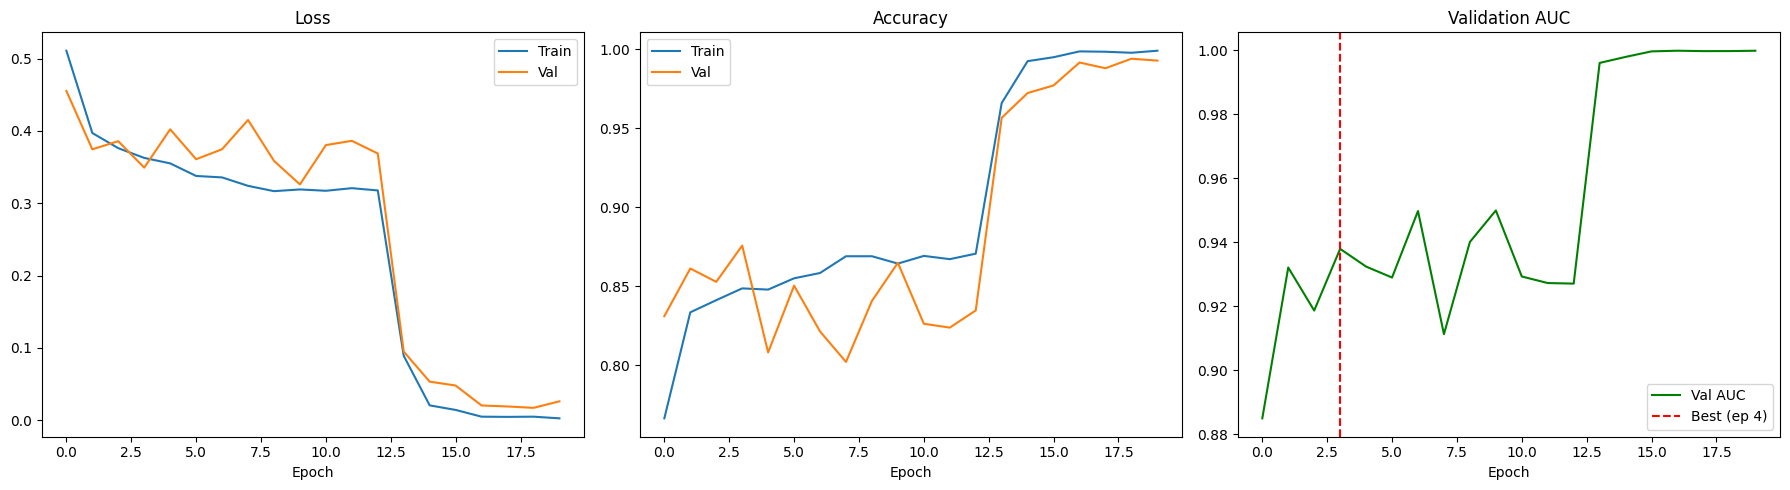

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"], label="Val")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(history["train_acc"], label="Train")
axes[1].plot(history["val_acc"], label="Val")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()

axes[2].plot(history["val_auc"], label="Val AUC", color="green")
axes[2].axvline(x=best_epoch - 1, color="red", linestyle="--", label=f"Best (ep {best_epoch})")
axes[2].set_title("Validation AUC"); axes[2].set_xlabel("Epoch"); axes[2].legend()

plt.tight_layout()
plt.savefig("training_history.png", dpi=150)
plt.show()

# **Cell 15: Evaluate on Test Set**

In [15]:
model.load_state_dict(torch.load("best_fracture_resnet50.pth"))
test_loss, test_acc, test_auc = evaluate(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f} | Test AUC: {test_auc:.4f}")

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

Test Loss: 0.0245 | Test Acc: 0.9901 | Test AUC: 0.9999

Classification Report:
               precision    recall  f1-score   support

    fractured       1.00      0.98      0.99       238
not fractured       0.99      1.00      0.99       268

     accuracy                           0.99       506
    macro avg       0.99      0.99      0.99       506
 weighted avg       0.99      0.99      0.99       506



# **Cell 16: Plot Confusion Matrix and ROC Curve**

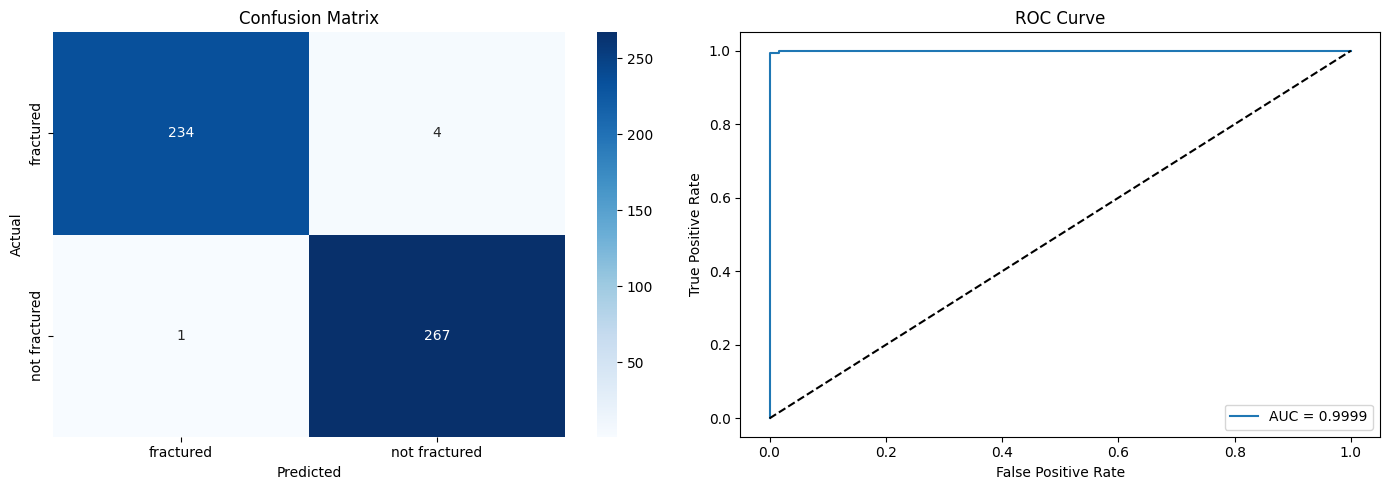

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=train_dataset.classes, yticklabels=train_dataset.classes)
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

model.eval()
probs = []
with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs.extend(torch.softmax(outputs, dim=1)[:, 1].cpu().numpy())
fpr, tpr, _ = roc_curve(all_labels, probs)
axes[1].plot(fpr, tpr, label=f"AUC = {test_auc:.4f}")
axes[1].plot([0, 1], [0, 1], "k--")
axes[1].set_title("ROC Curve")
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

plt.tight_layout()
plt.savefig("results.png", dpi=150)
plt.show()

# **Cell 17: Interpretability with Grad-CAM**

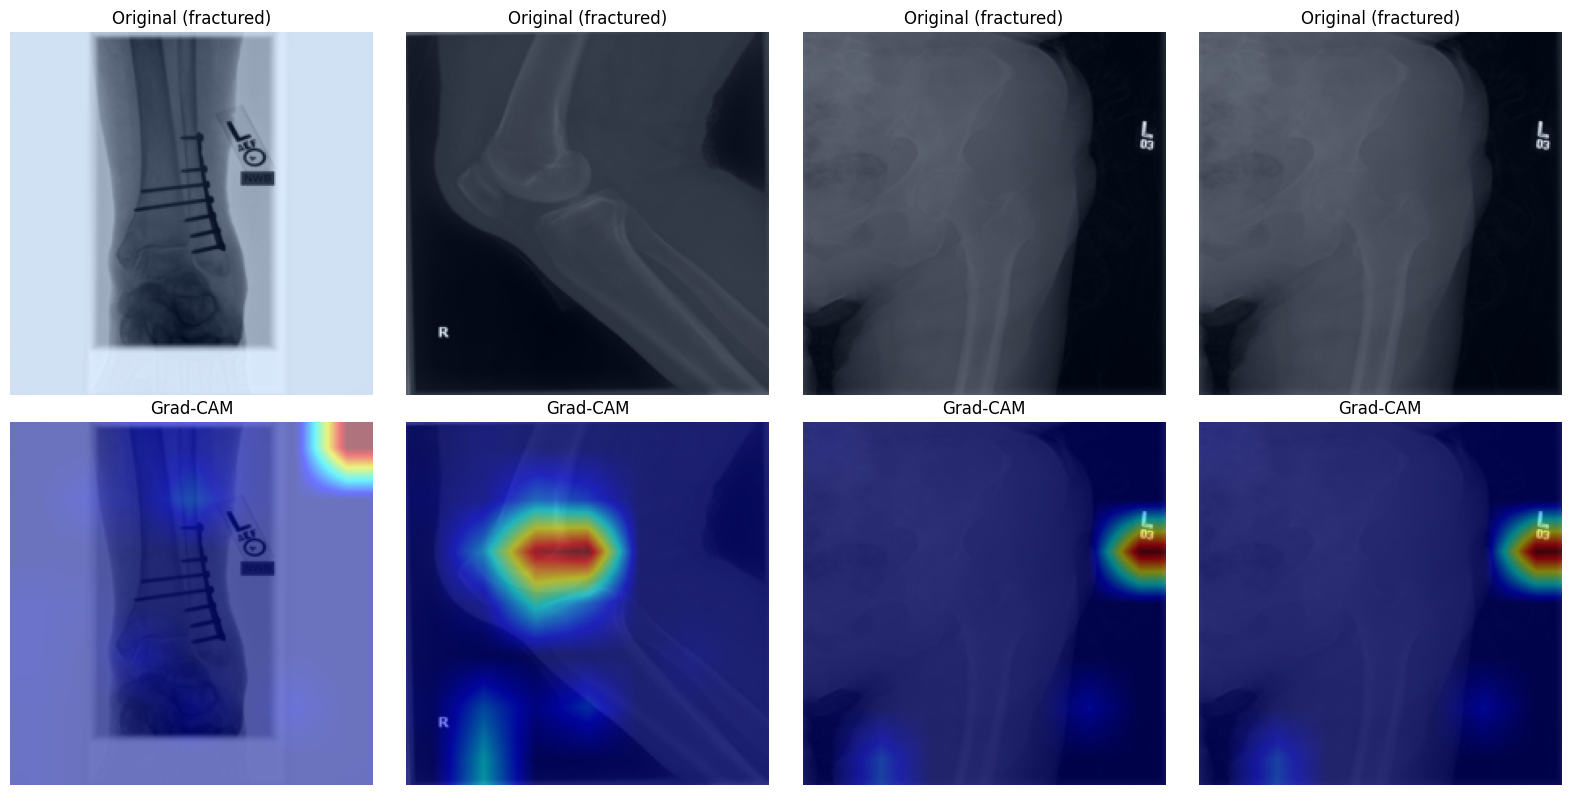

In [17]:
target_layers = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

sample_images, sample_labels = next(iter(test_loader))
sample_images = sample_images[:4].to(device)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(4):
    img_tensor = sample_images[i:i+1]
    grayscale_cam = cam(input_tensor=img_tensor, targets=[ClassifierOutputTarget(1)])[0]

    img_np = img_tensor[0].cpu().permute(1, 2, 0).numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())
    cam_image = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    axes[0, i].imshow(img_np)
    axes[0, i].set_title(f"Original ({train_dataset.classes[sample_labels[i]]})")
    axes[0, i].axis("off")
    axes[1, i].imshow(cam_image)
    axes[1, i].set_title("Grad-CAM")
    axes[1, i].axis("off")

plt.tight_layout()
plt.savefig("gradcam.png", dpi=150)
plt.show()

# **Cell 18: Save Model Weights and Config**

In [18]:
torch.save(model.state_dict(), "bone_fracture_resnet50_weights.pth")

config = {
    "architectures": ["ResNetForImageClassification"],
    "model_type": "resnet",
    "num_labels": 2,
    "id2label": {i: name for i, name in enumerate(train_dataset.classes)},
    "label2id": {name: i for i, name in enumerate(train_dataset.classes)},
}
with open("config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Files saved:")
print("  - bone_fracture_resnet50_weights.pth")
print("  - config.json")

Files saved:
  - bone_fracture_resnet50_weights.pth
  - config.json


# **Cell 19: Download Files from Colab**

In [19]:
from google.colab import files

files.download("bone_fracture_resnet50_weights.pth")
files.download("config.json")
files.download("training_history.png")
files.download("results.png")
files.download("gradcam.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>